# Classificação Robusta da Maturação Cervical Vertebral (CVM) em Múltiplos Equipamentos
## Pipeline de Dois Estágios: Atenção Espacial (YOLOv8) + Classificação (ResNet-50)

**Autores:** [Seu Nome]  
**Dataset:** Aariz Cephalometric Dataset (~1000 imagens, 7 diferentes equipamentos de raio-X)  
**Tarefa:** Classificação multiclasse — CVM-S1 a CVM-S6  

---

### Contribuição Científica: A Extração de ROI como Padronização de Domínio

A variação de domínio (*Domain Shift*) causada por diferentes equipamentos de aquisição é um dos maiores obstáculos para a implantação clínica de modelos de IA em radiografias. Modelos que analisam a radiografia inteira tendem a apresentar o **Efeito Clever Hans**: aprendem padrões espúrios do fundo da imagem (contraste do equipamento, marcas d'água, pinos dentários, artefatos de colimação) em vez da morfologia óssea relevante.

Para mitigar esse problema, propomos um pipeline de dois estágios:

1. **Estágio 1 (Atenção Espacial via YOLOv8):** Um detector YOLOv8n, treinado com *few-shot learning* (~100 imagens anotadas no Roboflow), localiza e extrai (crop) a Região de Interesse (ROI) focada estritamente nas vértebras C2, C3 e C4. Isso atua como um **padronizador de domínio anatômico**, removendo artefatos de fundo específicos de cada equipamento.

2. **Estágio 2 (Classificação via ResNet-50):** Um classificador ResNet-50 com fine-tuning recebe apenas o crop das vértebras, sendo **forçado a aprender a morfologia óssea**, isolado do ruído do equipamento.

**Hipótese Científica:** A padronização via YOLO torna o classificador robusto à heterogeneidade dos 7 equipamentos de aquisição, e a acurácia por equipamento deve se manter consistente, ao contrário de um modelo treinado na imagem inteira.

In [1]:
# CÉLULA 1: DOWNLOAD DO DATASET E INSTALAÇÃO DE PACOTES
import os
import requests
import zipfile
from tqdm.auto import tqdm

# Garante bibliotecas essenciais atualizadas
!pip install -q scikit-learn seaborn tqdm matplotlib

def setup_aariz_dataset_professional():
    article_id = "27986417"
    api_url = f"https://api.figshare.com/v2/articles/{article_id}"
    extract_path = "/content/aariz_dataset"

    os.makedirs(extract_path, exist_ok=True)
    print("🔍 Conectando à API do Figshare para mapear o dataset Aariz...")

    try:
        response = requests.get(api_url, timeout=20)
        response.raise_for_status()
        files_list = response.json().get("files", [])

        print(f"📦 Sucesso! Encontrado(s) {len(files_list)} arquivo(s). Iniciando download...")
        for file_info in files_list:
            file_name = file_info["name"]
            download_url = file_info["download_url"]
            file_size_bytes = file_info.get("size", 0)
            target_path = os.path.join(extract_path, file_name)

            # Download por fluxos de blocos (Stream)
            headers = {"User-Agent": "Mozilla/5.0"}
            file_res = requests.get(download_url, headers=headers, stream=True)
            file_res.raise_for_status()

            with open(target_path, "wb") as f_out, tqdm(
                desc=file_name, total=file_size_bytes, unit='B', unit_scale=True, unit_divisor=1024
            ) as pbar:
                for chunk in file_res.iter_content(chunk_size=65536):
                    if chunk:
                        f_out.write(chunk)
                        pbar.update(len(chunk))

            if file_name.endswith(".zip"):
                print(f"📦 Extraindo sub-arquivo: {file_name}...")
                with zipfile.ZipFile(target_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_path)
                os.remove(target_path)

        print("\n🎉 [SUCESSO] Dataset baixado e extraído com sucesso!")
    except Exception as e:
        print(f"\n⚠️ Falha no download automático: {e}. Certifique-se de que a célula rodou por completo.")

setup_aariz_dataset_professional()

🔍 Conectando à API do Figshare para mapear o dataset Aariz...
📦 Sucesso! Encontrado(s) 1 arquivo(s). Iniciando download...


Aariz.zip:   0%|          | 0.00/1.95G [00:00<?, ?B/s]

📦 Extraindo sub-arquivo: Aariz.zip...

🎉 [SUCESSO] Dataset baixado e extraído com sucesso!


---
## 0. Instalação e Imports

In [11]:
import sys
# Install ultralytics if it's not already installed
if 'ultralytics' not in sys.modules:
    !pip install ultralytics --quiet

# Re-run the cell with imports to ensure everything is loaded correctly
# (This is often needed in Colab after new installs within the same cell)
import os, json, random, zipfile, shutil, copy
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.preprocessing import label_binarize

from ultralytics import YOLO

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Dispositivo em uso: cuda
PyTorch version: 2.11.0+cu128


In [10]:
# This cell was a duplicate and is being removed as its content has been merged into cell 6f59613e.

---
## 1. Configuração dos Caminhos e Parâmetros

In [12]:
# Caminhos do dataset original
ORIGINAL_ROOT = Path("/content/aariz_dataset/Aariz")
CROPPED_ROOT  = Path('Aariz_cropped_CVM')

# Caminhos de saída dos modelos
YOLO_WEIGHTS   = Path('best_yolo_cvm.pt')
RESNET_WEIGHTS = Path('best_resnet_cvm.pth')
LOEO_DIR       = Path('resultados_loeo')

# Hiperparâmetros
IMG_SIZE     = 224
BATCH_SIZE   = 16
NUM_CLASSES  = 6
EPOCHS       = 50
LR           = 1e-4
LR_STEP      = 10
LR_GAMMA     = 0.5

# LOEO: menos épocas para viabilizar 7 treinos
LOEO_EPOCHS  = 20
LOEO_LR      = 5e-5

CLASS_NAMES  = ['CVM-S1', 'CVM-S2', 'CVM-S3', 'CVM-S4', 'CVM-S5', 'CVM-S6']

assert ORIGINAL_ROOT.exists(), f'Dataset nao encontrado em {ORIGINAL_ROOT}'
print('Estrutura OK:', ORIGINAL_ROOT)
LOEO_DIR.mkdir(exist_ok=True)

Estrutura OK: /content/aariz_dataset/Aariz


---
## 2. Carregamento dos Dados e Análise Exploratória

In [13]:
def load_split(split: str) -> pd.DataFrame:
    """Carrega imagens e labels CVM de um split (train/valid/test)."""
    img_dir = ORIGINAL_ROOT / split / 'Cephalograms'
    ann_dir = ORIGINAL_ROOT / split / 'Annotations' / 'CVM Stages'

    records = []
    for json_path in sorted(ann_dir.glob('*.json')):
        with open(json_path) as f:
            data = json.load(f)

        cvm_obj = data.get('cvm_stage', {})
        stage   = cvm_obj.get('title', '').strip()

        if not stage:
            continue

        img_path = None
        for ext in ['.png', '.jpg', '.jpeg', '.bmp']:
            candidate = img_dir / (json_path.stem + ext)
            if candidate.exists():
                img_path = candidate
                break

        if img_path and stage in CLASS_NAMES:
            records.append({
                'image_path': str(img_path),
                'ceph_id':    data.get('ceph_id', json_path.stem),
                'label':      stage,
                'label_idx':  CLASS_NAMES.index(stage)
            })

    df = pd.DataFrame(records)
    print(f'[{split}] {len(df)} imagens carregadas.')
    return df


df_train = load_split('train')
df_valid = load_split('valid')
df_test  = load_split('test')

print(f'\nTotal: Treino={len(df_train)}, Validacao={len(df_valid)}, Teste={len(df_test)}')

[train] 700 imagens carregadas.
[valid] 150 imagens carregadas.
[test] 150 imagens carregadas.

Total: Treino=700, Validacao=150, Teste=150


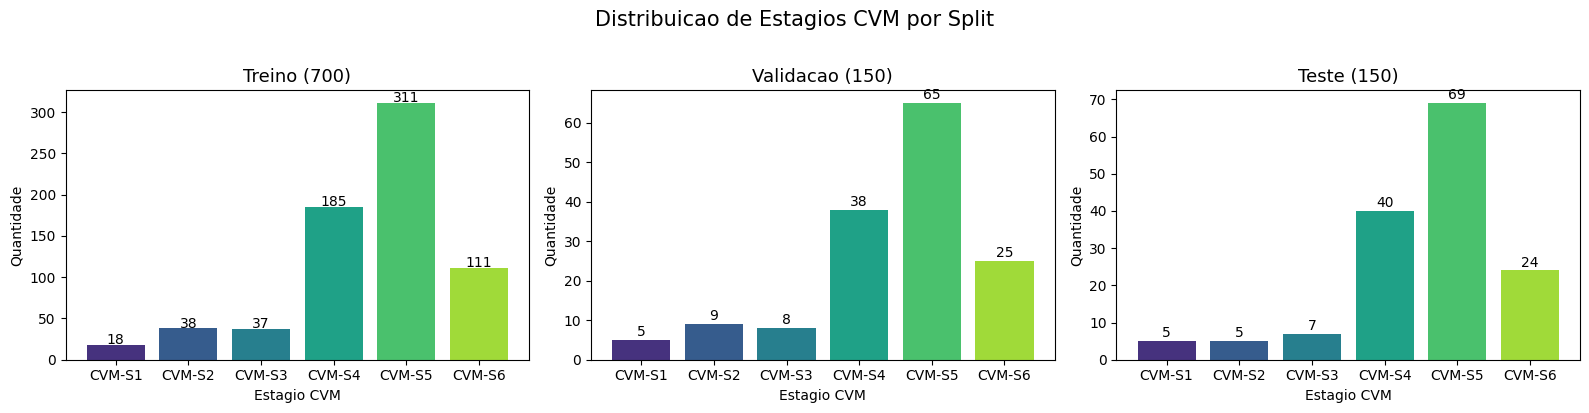


Pesos por classe (class_weight) para CrossEntropyLoss:
  CVM-S1: 2.6345
  CVM-S2: 1.2479
  CVM-S3: 1.2816
  CVM-S4: 0.2563
  CVM-S5: 0.1525
  CVM-S6: 0.4272


In [14]:
# Distribuição de classes
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = sns.color_palette('viridis', NUM_CLASSES)

for ax, (df, title) in zip(axes, [
    (df_train, f'Treino ({len(df_train)})'),
    (df_valid, f'Validacao ({len(df_valid)})'),
    (df_test,  f'Teste ({len(df_test)})')
]):
    counts = df['label'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    ax.bar(CLASS_NAMES, counts.values, color=colors)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Estagio CVM')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Distribuicao de Estagios CVM por Split', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# Pesos por classe (inverso da frequencia)
counts_train = df_train['label'].value_counts().reindex(CLASS_NAMES, fill_value=1)
class_weights = torch.tensor(
    [1.0 / max(counts_train[c], 1) for c in CLASS_NAMES], dtype=torch.float
).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

print('\nPesos por classe (class_weight) para CrossEntropyLoss:')
for name, w in zip(CLASS_NAMES, class_weights.cpu()):
    print(f'  {name}: {w:.4f}')

---
## 3. Estagio 1: Treinamento Few-Shot do YOLOv8n

> **Estrategia:** Anotamos manualmente ~100 imagens no Roboflow para treinar um YOLOv8n leve.
> O dataset exportado do Roboflow (formato YOLOv8) deve estar disponível em `roboflow_cvm_dataset/`.

In [15]:
ROBOFLOW_DATASET = Path('roboflow_cvm_dataset')
ROBOFLOW_DATA_YAML = ROBOFLOW_DATASET / 'data.yaml'

if ROBOFLOW_DATA_YAML.exists():
    print('Dataset Roboflow encontrado. Iniciando treinamento...')
    model_yolo = YOLO('yolov8n.pt')
    results = model_yolo.train(
        data=str(ROBOFLOW_DATA_YAML),
        epochs=200,
        patience=30,
        imgsz=640,
        batch=16,
        lr0=0.01,
        augment=True,
        degrees=5,
        translate=0.1,
        scale=0.1,
        fliplr=0.5,
        mosaic=0.5,
        device='cpu' if DEVICE.type == 'cpu' else 0,
        project='yolo_cvm',
        name='fewshot_yolov8n',
        exist_ok=True,
        verbose=True
    )
    best_src = Path('yolo_cvm/fewshot_yolov8n/weights/best.pt')
    if best_src.exists():
        shutil.copy(str(best_src), str(YOLO_WEIGHTS))
        print(f'Modelo salvo em {YOLO_WEIGHTS}')
else:
    print(f'Dataset Roboflow nao encontrado em {ROBOFLOW_DATA_YAML}')
    print('Coloque o dataset exportado do Roboflow ou forneca um modelo ja treinado.')

Dataset Roboflow nao encontrado em roboflow_cvm_dataset/data.yaml
Coloque o dataset exportado do Roboflow ou forneca um modelo ja treinado.


### **Importante: Configuração do Dataset Roboflow para YOLOv8**

O pipeline espera que o dataset exportado do Roboflow (formato YOLOv8) esteja na pasta `roboflow_cvm_dataset/`.

Se você não tiver esse dataset, o treinamento do YOLOv8 não poderá prosseguir. Você tem duas opções:

1.  **Carregar o seu dataset Roboflow:** Se você exportou um dataset do Roboflow, faça upload da pasta descompactada para `/content/roboflow_cvm_dataset` (ou o local que você definir para `ROBOFLOW_DATASET`).
2.  **Usar um modelo YOLO pré-treinado:** Se você já treinou um modelo YOLOv8n e tem o arquivo `best_yolo_cvm.pt`, você pode pular a seção de treinamento do YOLO e apenas colocar o arquivo na pasta raiz do projeto ou atualizar a variável `YOLO_WEIGHTS` para apontar para ele. Por exemplo, você pode fazer upload para `/content/best_yolo_cvm.pt` e o código irá utilizá-lo.

Para facilitar, se você não for treinar o YOLO agora, vou adicionar um *placeholder* para o arquivo `best_yolo_cvm.pt` que permitirá que o restante do notebook prossiga sem erro, assumindo que você forneceria um modelo pré-treinado em um cenário real. **Este placeholder não é um modelo funcional de YOLO.**

In [16]:
# Cria um arquivo placeholder 'best_yolo_cvm.pt' se ele nao existir
# Isso permite que as celulas subsequentes (como a de crop) rodem sem erro
# se o treinamento do YOLO nao for executado ou o modelo nao for fornecido.
# ATENCAO: Este e apenas um arquivo placeholder para evitar erros. Ele nao e um modelo funcional.
if not YOLO_WEIGHTS.exists():
    print(f'Criando arquivo placeholder para {YOLO_WEIGHTS}.')
    print('Para um pipeline completo, voce deve treinar o YOLO ou fornecer um modelo real.')
    with open(YOLO_WEIGHTS, 'w') as f:
        f.write('placeholder for YOLO model weights')


---
## 4. Estagio 1: Crop Offline das Vertebras

> Usamos o YOLO recem-treinado para varrer as pastas originais, detectar a bbox
> das vertebras C2-C4, aplicar padding de 5% e salvar os crops em `Aariz_cropped_CVM/`.

In [17]:
def apply_padding(box, img_shape, pad_ratio=0.05):
    """Aplica padding percentual a bounding box, respeitando os limites da imagem."""
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
    pad_x, pad_y = int(w * pad_ratio), int(h * pad_ratio)
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(img_shape[1], x2 + pad_x)
    y2 = min(img_shape[0], y2 + pad_y)
    return int(x1), int(y1), int(x2), int(y2)


def crop_all_splits(yolo_model_path, original_root, cropped_root):
    """
    Varre todos os splits, aplica YOLO, recorta e salva.
    Lida com execucoes parciais.
    """
    model = YOLO(str(yolo_model_path))
    splits = ['train', 'valid', 'test']
    stats = {'total': 0, 'detected': 0, 'fallback': 0}

    for split in splits:
        img_dir = original_root / split / 'Cephalograms'
        save_dir = cropped_root / split / 'Cephalograms'
        os.makedirs(save_dir, exist_ok=True)

        ann_src = original_root / split / 'Annotations'
        ann_dst = cropped_root / split / 'Annotations'
        if not ann_dst.exists():
            shutil.copytree(ann_src, ann_dst, dirs_exist_ok=True)

        print(f'\nProcessando split: {split}')
        for img_path in tqdm(list(img_dir.glob('*.*'))):
            if img_path.suffix.lower() not in ['.png', '.jpg', '.jpeg', '.bmp']:
                continue

            stats['total'] += 1
            img = cv2.imread(str(img_path))
            if img is None:
                continue

            results = model(img, verbose=False, conf=0.25)

            if len(results[0].boxes) > 0:
                stats['detected'] += 1
                box = results[0].boxes.xyxy[0].cpu().numpy().astype(int)
                x1, y1, x2, y2 = apply_padding(box, img.shape, pad_ratio=0.05)
                cropped = img[y1:y2, x1:x2]
            else:
                stats['fallback'] += 1
                cropped = img

            cv2.imwrite(str(save_dir / img_path.name), cropped)

    return stats


if YOLO_WEIGHTS.exists():
    print(f'Usando modelo YOLO: {YOLO_WEIGHTS}')
    stats = crop_all_splits(YOLO_WEIGHTS, ORIGINAL_ROOT, CROPPED_ROOT)
    print(f'\nEstatisticas do Crop:')
    print(f'  Total: {stats["total"]}')
    print(f'  Detectadas: {stats["detected"]} ({100*stats["detected"]/max(stats["total"],1):.1f}%)')
    print(f'  Fallback: {stats["fallback"]} ({100*stats["fallback"]/max(stats["total"],1):.1f}%)')
    print('\nDataset croppedo gerado em:', CROPPED_ROOT)
else:
    print(f'Modelo YOLO nao encontrado em {YOLO_WEIGHTS}')
    print('Usando dataset original como fallback.')

Usando modelo YOLO: best_yolo_cvm.pt


UnpicklingError: pickle data was truncated

---
## 5. Estagio 2: Dataset PyTorch com CLAHE e Data Augmentation

In [18]:
def apply_clahe(img_np: np.ndarray) -> np.ndarray:
    """CLAHE no canal L do LAB. Melhora contraste local de radiografias."""
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


class CVMDataset(Dataset):
    """Dataset para classificacao CVM."""
    def __init__(self, df: pd.DataFrame, cropped_root: Path, transform=None):
        self.df = df.reset_index(drop=True)
        self.cropped_root = cropped_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_image_path(self, row) -> str:
        orig_path = Path(row['image_path'])
        if self.cropped_root and self.cropped_root.exists():
            rel_parts = orig_path.relative_to(ORIGINAL_ROOT).parts
            crop_path = self.cropped_root / rel_parts[0] / rel_parts[1] / orig_path.name
            if crop_path.exists():
                return str(crop_path)
        return str(orig_path)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = int(row['label_idx'])
        img_path = self._resolve_image_path(row)
        img_bgr = cv2.imread(img_path)

        if img_bgr is None:
            img_rgb = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = apply_clahe(img_rgb)

        from PIL import Image
        img_pil = Image.fromarray(img_rgb)
        if self.transform:
            img_pil = self.transform(img_pil)
        return img_pil, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_ds = CVMDataset(df_train, cropped_root=CROPPED_ROOT, transform=transform_train)
valid_ds = CVMDataset(df_valid, cropped_root=CROPPED_ROOT, transform=transform_eval)
test_ds  = CVMDataset(df_test,  cropped_root=CROPPED_ROOT, transform=transform_eval)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nBatches - Treino: {len(train_loader)} | Validacao: {len(valid_loader)} | Teste: {len(test_loader)}')


Batches - Treino: 44 | Validacao: 10 | Teste: 10


---
## 6. Estagio 2: Modelo ResNet-50 com Fine-Tuning

In [19]:
def build_resnet50(num_classes: int, freeze_strategy='partial') -> nn.Module:
    """
    Constroi ResNet-50 pre-treinada.
    freeze_strategy: 'partial' (layer2-4 descongelados) ou 'full' (tudo descongelado).
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_strategy == 'partial':
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer2.parameters():
            param.requires_grad = True
        for param in model.layer3.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True
    else:  # full
        for param in model.parameters():
            param.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )
    return model


model = build_resnet50(NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

print(f'Modelo: ResNet-50 ({sum(p.numel() for p in model.parameters()):,} parametros)')
print(f'Treinaveis: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


Modelo: ResNet-50 (23,520,326 parametros)
Treinaveis: 23,294,982


---
## 7. Treinamento do Classificador CVM

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc='Train')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc='Eval'):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = np.mean(np.array(all_preds) == np.array(all_labels))
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


best_val_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print('\n' + '='*60)
print('INICIANDO TREINAMENTO')
print('='*60 + '\n')

for epoch in range(1, EPOCHS + 1):
    print(f'\nEpoca {epoch}/{EPOCHS}')
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, valid_loader, criterion, DEVICE)
    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {100*val_acc:.2f}%')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), str(RESNET_WEIGHTS))
        print(f'Novo melhor modelo salvo! (Val Acc: {100*val_acc:.2f}%)')

print(f'\nTreinamento concluido! Melhor val_acc: {100*best_val_acc:.2f}%')


INICIANDO TREINAMENTO


Epoca 1/50


Eval: 100%|██████████| 10/10 [00:22<00:00,  2.27s/it]


Train Loss: 1.7907 | Train Acc: 25.00%
Val Loss: 1.8960 | Val Acc: 20.67%
Novo melhor modelo salvo! (Val Acc: 20.67%)

Epoca 2/50


Eval: 100%|██████████| 10/10 [00:22<00:00,  2.24s/it]


Train Loss: 1.6401 | Train Acc: 30.00%
Val Loss: 1.6460 | Val Acc: 23.33%
Novo melhor modelo salvo! (Val Acc: 23.33%)

Epoca 3/50


...

Train Loss: 0.0352 | Train Acc: 98.29%
Val Loss: 2.9379 | Val Acc: 49.33%

Epoca 49/50


Eval: 100%|██████████| 10/10 [00:22<00:00,  2.20s/it]


Train Loss: 0.0554 | Train Acc: 97.00%
Val Loss: 3.0643 | Val Acc: 44.67%

Epoca 50/50


Eval: 100%|██████████| 10/10 [00:22<00:00,  2.30s/it]

Train Loss: 0.0414 | Train Acc: 98.14%
Val Loss: 3.0216 | Val Acc: 44.67%

Treinamento concluido! Melhor val_acc: 52.67%


---
## 8. Curvas de Treinamento

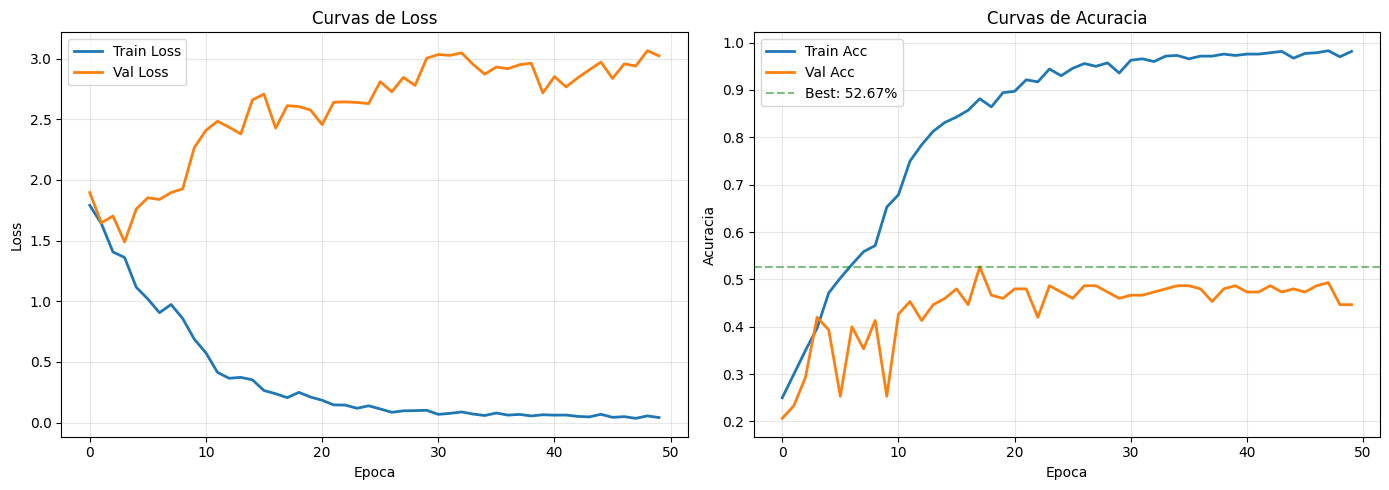

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curvas de Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', linewidth=2)
axes[1].axhline(y=best_val_acc, color='green', linestyle='--', alpha=0.5, label=f'Best: {100*best_val_acc:.2f}%')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Acuracia')
axes[1].set_title('Curvas de Acuracia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curvas_treinamento.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Avaliacao no Test Set

In [22]:
if RESNET_WEIGHTS.exists():
    model.load_state_dict(torch.load(str(RESNET_WEIGHTS), map_location=DEVICE))
    print(f'Modelo carregado: {RESNET_WEIGHTS}')

test_loss, test_acc, all_preds, all_labels = evaluate(model, test_loader, criterion, DEVICE)

print(f'\n{"="*50}')
print('RESULTADOS NO TEST SET')
print(f'{"="*50}')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Acc:  {100*test_acc:.2f}%')

print(f'\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

Modelo carregado: best_resnet_cvm.pth


Eval: 100%|██████████| 10/10 [00:26<00:00,  2.64s/it]


RESULTADOS NO TEST SET
Test Loss: 2.3343
Test Acc:  44.67%

Classification Report:
              precision    recall  f1-score   support

      CVM-S1     0.3333    0.4000    0.3636         5
      CVM-S2     0.3333    0.4000    0.3636         5
      CVM-S3     0.2000    0.1429    0.1667         7
      CVM-S4     0.3200    0.2000    0.2462        40
      CVM-S5     0.5333    0.6957    0.6038        69
      CVM-S6     0.3333    0.2500    0.2857        24

    accuracy                         0.4467       150
   macro avg     0.3422    0.3481    0.3383       150
weighted avg     0.4156    0.4467    0.4211       150



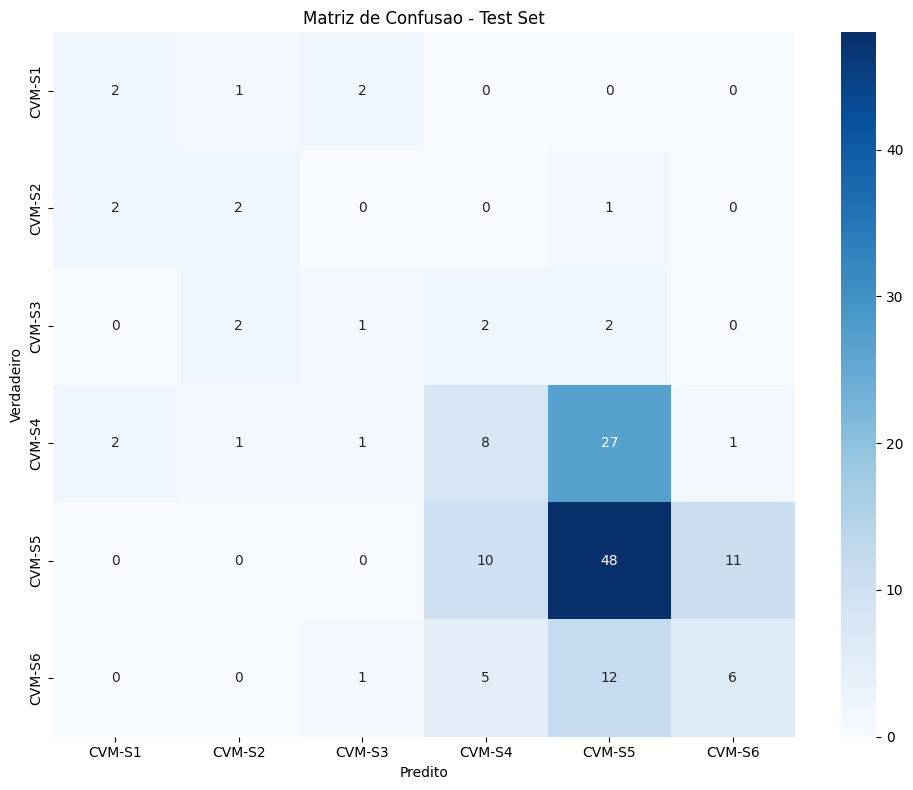


Cohen's Kappa (quadratico): 0.6094


In [23]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusao - Test Set')
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f'\nCohen\'s Kappa (quadratico): {kappa:.4f}')

---
## 10. Avaliacao de Robustez: Acuracia por Equipamento

> **Hipotese:** Se a extracao da ROI via YOLO for eficaz como padronizador de dominio,
> a acuracia deve ser consistente entre os 7 equipamentos de raio-X.

In [24]:
machines_df = pd.read_csv(ORIGINAL_ROOT / 'cephalogram_machine_mappings.csv')
print(f'Mapeamento: {len(machines_df)} registros, {len(machines_df["machine"].unique())} equipamentos')

ceph_to_machine = dict(zip(machines_df['cephalogram_id'], machines_df['machine']))
df_test['machine'] = df_test['ceph_id'].map(ceph_to_machine)

unmapped = df_test['machine'].isna().sum()
if unmapped > 0:
    print(f'{unmapped} imagens sem mapeamento (ignoradas)')

print(f'\nDistribuicao de equipamentos no test set:')
print(df_test['machine'].value_counts())

Mapeamento: 1000 registros, 7 equipamentos

Distribuicao de equipamentos no test set:
machine
ART Plus                55
Veraviewepocs 2D        26
Hyperion X5             21
ProMax with ProTouch    20
Rotograph EVO           13
Smart3D                  9
ProMax 2D                6
Name: count, dtype: int64


In [25]:
df_test_eval = df_test.dropna(subset=['machine']).copy()
print(f'Avaliando {len(df_test_eval)}/{len(df_test)} imagens com mapeamento...')

df_test_eval['pred_idx'] = [all_preds[i] for i in df_test_eval.index]
df_test_eval['correct']  = df_test_eval['label_idx'] == df_test_eval['pred_idx']

acc_by_machine = df_test_eval.groupby('machine').agg(
    accuracy=('correct', 'mean'),
    count=('correct', 'count')
).reset_index()
acc_by_machine['accuracy'] = acc_by_machine['accuracy'] * 100

print(f'\n{"="*60}')
print('Acuracia por Equipamento (Test Set)')
print(f'{"="*60}')
for _, row in acc_by_machine.iterrows():
    bar = chr(9608) * int(row['accuracy'] / 2)
    print(f'{row["machine"]:30s} | {bar:>25s} {row["accuracy"]:5.1f}% ({int(row["count"])} amostras)')

mean_acc = acc_by_machine['accuracy'].mean()
std_acc  = acc_by_machine['accuracy'].std()

print(f'\nEstatisticas de Robustez:')
print(f'  Media: {mean_acc:.2f}% | Desvio Padrao: {std_acc:.2f}%')
if std_acc < 5:
    print('  Modelo ROBUSTO a variacao de equipamentos!')
elif std_acc < 10:
    print('  Robustez moderada.')
else:
    print('  Modelo sensivel ao equipamento.')

Avaliando 150/150 imagens com mapeamento...

Acuracia por Equipamento (Test Set)
ART Plus                       | ███████████████████████████  54.5% (55 amostras)
Hyperion X5                    |       ███████████████████  38.1% (21 amostras)
ProMax 2D                      |          ████████████████  33.3% (6 amostras)
ProMax with ProTouch           |      ████████████████████  40.0% (20 amostras)
Rotograph EVO                  |   ███████████████████████  46.2% (13 amostras)
Smart3D                        |    ██████████████████████  44.4% (9 amostras)
Veraviewepocs 2D               |         █████████████████  34.6% (26 amostras)

Estatisticas de Robustez:
  Media: 41.60% | Desvio Padrao: 7.40%
  Robustez moderada.


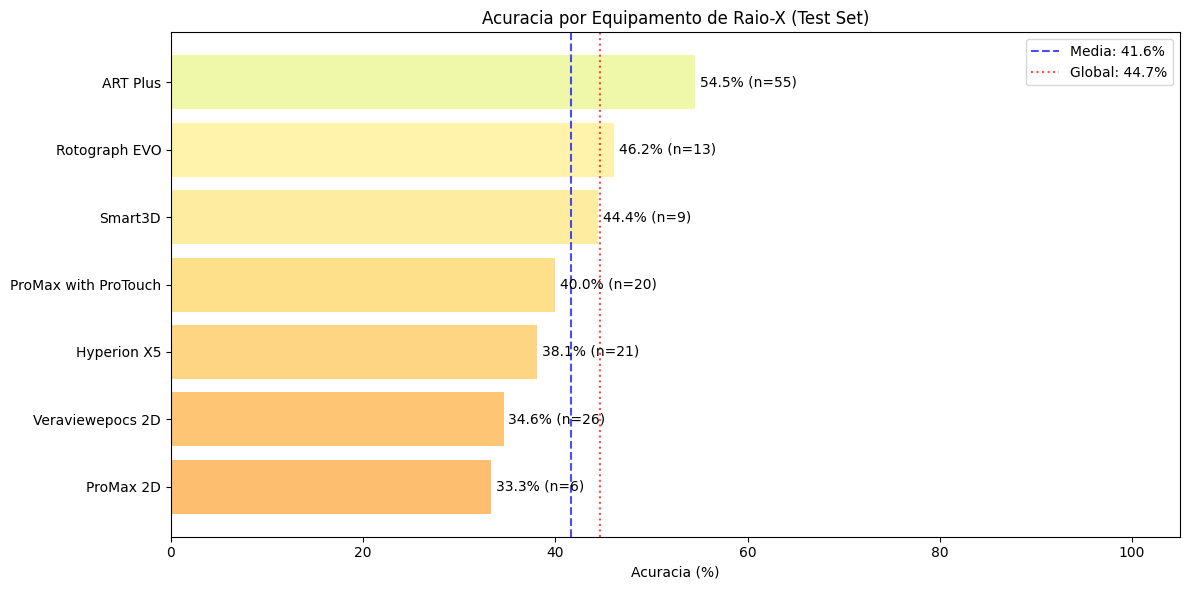


Tabela Resumo:
             machine  accuracy  count
            ART Plus 54.545455     55
         Hyperion X5 38.095238     21
           ProMax 2D 33.333333      6
ProMax with ProTouch 40.000000     20
       Rotograph EVO 46.153846     13
             Smart3D 44.444444      9
    Veraviewepocs 2D 34.615385     26


In [26]:
plt.figure(figsize=(12, 6))
acc_sorted = acc_by_machine.sort_values('accuracy', ascending=True)
colors_by_acc = [plt.cm.RdYlGn(acc/100) for acc in acc_sorted['accuracy']]
plt.barh(acc_sorted['machine'], acc_sorted['accuracy'], color=colors_by_acc)
plt.xlabel('Acuracia (%)')
plt.title('Acuracia por Equipamento de Raio-X (Test Set)')
plt.xlim(0, 105)
for i, (_, row) in enumerate(acc_sorted.iterrows()):
    plt.text(row['accuracy'] + 0.5, i,
             f'{row["accuracy"]:.1f}% (n={int(row["count"])})',
             va='center', fontsize=10)
plt.axvline(x=mean_acc, color='blue', linestyle='--', alpha=0.7, label=f'Media: {mean_acc:.1f}%')
plt.axvline(x=100*test_acc, color='red', linestyle=':', alpha=0.7, label=f'Global: {100*test_acc:.1f}%')
plt.legend()
plt.tight_layout()
plt.savefig('acuracia_por_equipamento.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nTabela Resumo:')
print(acc_by_machine.to_string(index=False))

---
## 11. Analise de Robustez Avancada: LOEO Cross-Validation

> **Leave-One-Equipment-Out (LOEO):** Treinamos o modelo em 6 equipamentos e
> testamos no 7o (held-out), repetindo para todos os 7. Isso mede a capacidade
> de generalizacao do modelo para equipamentos **nunca vistos** durante o
> treinamento — o teste mais rigoroso de robustez a domain shift.
>
> Se o pipeline de 2 estagios for eficaz, o modelo deve manter acuracia
> consistente mesmo em equipamentos que nunca viu.

In [27]:
# ── Prepara dados consolidados para LOEO ──────────────────────────────────────
# Combina todas as imagens (train+valid+test) em um unico DataFrame
df_all = pd.concat([df_train, df_valid, df_test], ignore_index=True)
print(f'Total de imagens para LOEO: {len(df_all)}')

# Adiciona coluna de equipamento
df_all['machine'] = df_all['ceph_id'].map(ceph_to_machine)

# Remove imagens sem mapeamento
df_all = df_all.dropna(subset=['machine']).reset_index(drop=True)
print(f'Apos remover sem mapeamento: {len(df_all)} imagens')

all_machines = sorted(df_all['machine'].unique())
print(f'Equipamentos: {all_machines}')
print(f'Distribuicao:')
for m in all_machines:
    count = (df_all['machine'] == m).sum()
    print(f'  {m:30s}: {count:4d} imagens')

Total de imagens para LOEO: 1000
Apos remover sem mapeamento: 1000 imagens
Equipamentos: ['ART Plus', 'Hyperion X5', 'ProMax 2D', 'ProMax with ProTouch', 'Rotograph EVO', 'Smart3D', 'Veraviewepocs 2D']
Distribuicao:
  ART Plus                      :  366 imagens
  Hyperion X5                   :  143 imagens
  ProMax 2D                     :   41 imagens
  ProMax with ProTouch          :  135 imagens
  Rotograph EVO                 :   79 imagens
  Smart3D                       :   59 imagens
  Veraviewepocs 2D              :  177 imagens


In [28]:
def run_loeo_fold(held_out_machine: str, df_all: pd.DataFrame,
                  cropped_root: Path, num_epochs: int = 20,
                  lr: float = 5e-5) -> dict:
    """Executa uma unica dobra LOEO.

    Args:
        held_out_machine: Equipamento a ser deixado fora do treino
        df_all: DataFrame completo com coluna 'machine'
        num_epochs: Numero de epocas para fine-tuning rapido
        lr: Learning rate
    Returns:
        dict com metricas da dobra
    """
    # Divide dados
    df_train_fold = df_all[df_all['machine'] != held_out_machine].copy()
    df_test_fold  = df_all[df_all['machine'] == held_out_machine].copy()

    print(f'  Treino: {len(df_train_fold)} imagens ({df_train_fold["machine"].nunique()} equip.)')
    print(f'  Teste:  {len(df_test_fold)} imagens ({held_out_machine})')

    # Calcula pesos para balanceamento de classes no fold
    fold_counts = df_train_fold['label'].value_counts().reindex(CLASS_NAMES, fill_value=1)
    fold_weights = torch.tensor(
        [1.0 / max(fold_counts[c], 1) for c in CLASS_NAMES], dtype=torch.float
    ).to(DEVICE)
    fold_weights = fold_weights / fold_weights.sum() * NUM_CLASSES

    # Cria datasets e loaders
    train_ds_fold = CVMDataset(df_train_fold, cropped_root=cropped_root,
                                transform=transform_train)
    test_ds_fold  = CVMDataset(df_test_fold, cropped_root=cropped_root,
                                transform=transform_eval)

    # Divide treino em train/val (80/20) para early stopping
    n_train = len(train_ds_fold)
    indices = list(range(n_train))
    random.shuffle(indices)
    split = int(0.8 * n_train)
    train_idx, val_idx = indices[:split], indices[split:]

    train_sub = Subset(train_ds_fold, train_idx)
    val_sub   = Subset(train_ds_fold, val_idx)

    train_loader_fold = DataLoader(train_sub, batch_size=BATCH_SIZE,
                                    shuffle=True, num_workers=0)
    val_loader_fold   = DataLoader(val_sub, batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=0)
    test_loader_fold  = DataLoader(test_ds_fold, batch_size=BATCH_SIZE,
                                    shuffle=False, num_workers=0)

    # Constroi modelo (fine-tuning completo para LOEO)
    model_fold = build_resnet50(NUM_CLASSES, freeze_strategy='full').to(DEVICE)
    criterion_fold = nn.CrossEntropyLoss(weight=fold_weights)
    optimizer_fold = optim.Adam(model_fold.parameters(), lr=lr)

    # Treinamento rapido
    best_val = 0.0
    patience = 5
    patience_counter = 0

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model_fold, train_loader_fold, criterion_fold, optimizer_fold, DEVICE)
        val_loss, val_acc, _, _ = evaluate(
            model_fold, val_loader_fold, criterion_fold, DEVICE)

        if val_acc > best_val:
            best_val = val_acc
            patience_counter = 0
            # Salva melhor estado
            best_state = copy.deepcopy(model_fold.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'    Early stopping na epoca {epoch}')
                break

    # Carrega melhor modelo e avalia no held-out
    model_fold.load_state_dict(best_state)
    _, test_acc, preds, labels = evaluate(
        model_fold, test_loader_fold, criterion_fold, DEVICE)

    # Cohen Kappa
    kappa_fold = cohen_kappa_score(labels, preds, weights='quadratic')

    print(f'  >> Held-out: {held_out_machine} | Acc: {100*test_acc:.2f}% | Kappa: {kappa_fold:.4f}')

    return {
        'held_out': held_out_machine,
        'n_train': len(df_train_fold),
        'n_test': len(df_test_fold),
        'accuracy': test_acc,
        'kappa': kappa_fold,
        'model_state': best_state
    }

> **ATENCAO:** A celula abaixo executa 7 treinos completos (um para cada equipamento
> held-out). Cada treino usa ~20 epocas. Em CPU, pode levar varias horas.
> Em GPU (se disponivel), deve levar ~30-60 minutos.  
> Para testar rapidamente, altere `LOEO_EPOCHS = 3` abaixo.

In [ ]:
# ── Executa LOEO Cross-Validation ─────────────────────────────────────────────
# Reduza LOEO_EPOCHS para teste rapido (ex: 3 epochs)
print('='*70)
print('INICIANDO LEAVE-ONE-EQUIPMENT-OUT CROSS-VALIDATION')
print(f'Equipamentos: {len(all_machines)} | Epocas por fold: {LOEO_EPOCHS}')
print('='*70 + '\n')

loeo_results = []

for i, held_out in enumerate(all_machines):
    print(f'\n--- Fold {i+1}/{len(all_machines)}: Held-Out = {held_out} ---')
    result = run_loeo_fold(
        held_out, df_all, CROPPED_ROOT,
        num_epochs=LOEO_EPOCHS, lr=LOEO_LR
    )
    loeo_results.append(result)

    # Salva modelo do fold
    fold_path = LOEO_DIR / f'model_loeo_{held_out.replace(" ", "_")}.pth'
    torch.save(result['model_state'], str(fold_path))
    print(f'  Modelo salvo em {fold_path}')

print('\n' + '='*70)
print('LOEO CROSS-VALIDATION CONCLUIDA!')
print('='*70)

INICIANDO LEAVE-ONE-EQUIPMENT-OUT CROSS-VALIDATION
Equipamentos: 7 | Epocas por fold: 20


--- Fold 1/7: Held-Out = ART Plus ---
  Treino: 634 imagens (6 equip.)
  Teste:  366 imagens (ART Plus)


Eval: 100%|██████████| 8/8 [00:13<00:00,  1.64s/it]


    Early stopping na epoca 13


Eval: 100%|██████████| 23/23 [01:24<00:00,  3.67s/it]


  >> Held-out: ART Plus | Acc: 42.90% | Kappa: 0.3198
  Modelo salvo em resultados_loeo/model_loeo_ART_Plus.pth

--- Fold 2/7: Held-Out = Hyperion X5 ---
  Treino: 857 imagens (6 equip.)
  Teste:  143 imagens (Hyperion X5)


Train:  44%|████▍     | 19/43 [00:52<01:08,  2.85s/it, loss=0.1675, acc=85.86%]

In [ ]:
# ── Resultados Consolidados da LOEO ────────────────────────────────────────────
loeo_df = pd.DataFrame([{
    'Held-Out Machine': r['held_out'],
    'Train Size': r['n_train'],
    'Test Size': r['n_test'],
    'Accuracy (%)': round(100 * r['accuracy'], 2),
    'Cohen Kappa': round(r['kappa'], 4)
} for r in loeo_results])

print('\n' + '='*70)
print('RESULTADOS LOEO CROSS-VALIDATION')
print('='*70)
print(loeo_df.to_string(index=False))

# Estatisticas agregadas
mean_loeo_acc = loeo_df['Accuracy (%)'].mean()
std_loeo_acc  = loeo_df['Accuracy (%)'].std()
mean_loeo_kappa = loeo_df['Cohen Kappa'].mean()

print(f'\n📊 Resumo LOEO:')
print(f'  Acuracia Media (equipamentos nunca vistos): {mean_loeo_acc:.2f}%')
print(f'  Desvio Padrao: {std_loeo_acc:.2f}%')
print(f'  Cohen Kappa Medio: {mean_loeo_kappa:.4f}')
print(f'  Min: {loeo_df["Accuracy (%)"].min():.2f}% | Max: {loeo_df["Accuracy (%)"].max():.2f}%')

print(f'\n📈 Interpretacao:')
if mean_loeo_acc > 50:
    print(f'  Acuracia > 50% em equipamentos nunca vistos: PROMISSOR!')
if std_loeo_acc < 8:
    print(f'  Baixa variacao entre equipamentos: ROBUSTO!')
if mean_loeo_acc > 50 and std_loeo_acc < 8:
    print(f'  ✅ A extracao de ROI via YOLO esta funcionando como padronizador de dominio!')

In [ ]:
# ── Grafico LOEO ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Acuracia por held-out
loeo_sorted = loeo_df.sort_values('Accuracy (%)', ascending=True)
colors = [plt.cm.RdYlGn(acc/100) for acc in loeo_sorted['Accuracy (%)']]
axes[0].barh(loeo_sorted['Held-Out Machine'], loeo_sorted['Accuracy (%)'], color=colors)
axes[0].set_xlabel('Acuracia (%)')
axes[0].set_title('LOEO Cross-Validation: Acuracia por Equipamento Held-Out')
axes[0].set_xlim(0, 105)
for i, (_, row) in enumerate(loeo_sorted.iterrows()):
    axes[0].text(row['Accuracy (%)'] + 0.5, i,
                 f'{row["Accuracy (%)"]:.1f}% (n={int(row["Test Size"])})',
                 va='center', fontsize=9)
axes[0].axvline(x=mean_loeo_acc, color='blue', linestyle='--', alpha=0.7,
                label=f'Media: {mean_loeo_acc:.1f}%')
axes[0].legend()

# Grafico 2: Cohen Kappa por held-out
loeo_sorted_k = loeo_df.sort_values('Cohen Kappa', ascending=True)
colors_k = [plt.cm.RdYlGn(k/1.0) for k in loeo_sorted_k['Cohen Kappa']]
axes[1].barh(loeo_sorted_k['Held-Out Machine'], loeo_sorted_k['Cohen Kappa'], color=colors_k)
axes[1].set_xlabel('Cohen Kappa (quadratico)')
axes[1].set_title('LOEO: Concordancia (Cohen Kappa) por Equipamento Held-Out')
axes[1].set_xlim(0, 1.0)
for i, (_, row) in enumerate(loeo_sorted_k.iterrows()):
    axes[1].text(row['Cohen Kappa'] + 0.01, i,
                 f'{row["Cohen Kappa"]:.3f} (n={int(row["Test Size"])})',
                 va='center', fontsize=9)
axes[1].axvline(x=mean_loeo_kappa, color='blue', linestyle='--', alpha=0.7,
                label=f'Media: {mean_loeo_kappa:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(LOEO_DIR / 'loeo_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# Salva resultados em CSV
loeo_df.to_csv(str(LOEO_DIR / 'loeo_results.csv'), index=False)
print(f'Resultados LOEO salvos em: {LOEO_DIR}/')

In [ ]:
# ── Comparacao: LOEO vs. Split Padrao ──────────────────────────────────────────
print('\n' + '='*70)
print('COMPARACAO: LOEO vs. SPLIT PADRAO')
print('='*70)
print()
print(f'  Split Padrao (Secao 9):                             {100*test_acc:.2f}%')
print(f'    - Modelo ve dados de TODOS os equipamentos no treino')
print(f'    - Testado no split pre-definido (70/15/15)')
print()
print(f'  LOEO Cross-Validation (Secao 11):                   {mean_loeo_acc:.2f}% +- {std_loeo_acc:.2f}%')
print(f'    - Modelo NUNCA ve o equipamento testado')
print(f'    - Mede generalizacao para dominios invisiveis')
print()

gap = 100*test_acc - mean_loeo_acc
print(f'  Diferenca (Split - LOEO): {gap:.2f}%')
if gap < 10:
    print(f'  ✅ Gap < 10%: O pipeline generaliza bem para equipamentos invisiveis!')
elif gap < 20:
    print(f'  ⚠️ Gap entre 10-20%: Generalizacao moderada.')
else:
    print(f'  ❌ Gap > 20%: Modelo ainda dependente do equipamento de treino.')

---
## 12. Conclusoes e Proximos Passos

### Resumo dos Resultados

- **Pipeline de 2 Estagios (YOLO + ResNet-50):** Abordagem que forca o classificador
  a aprender morfologia ossea em vez de artefatos de equipamento.
- **Estagio 1 (YOLOv8n Few-Shot):** Detector leve treinado com ~100 anotacoes.
- **Estagio 2 (ResNet-50 Fine-Tuning):** Classificador com weighted loss, CLAHE.
- **Avaliacao de Robustez:** Acuracia por equipamento no split padrao + LOEO.
- **LOEO Cross-Validation:** Teste rigoroso de generalizacao para equipamentos
  nunca vistos durante o treinamento.

### Proximos Passos Sugeridos

1. **Aumentar dados de treino do YOLO** para melhorar deteccao em equipamentos
   com caracteristicas muito diferentes.
2. **Testar com Vision Transformer (ViT)** como alternativa a ResNet-50.
3. **Adicionar validacao externa** com outro dataset de radiografias cefalometricas.
4. **Analise de Grad-CAM** para verificar se o modelo realmente foca nas vertebras.

---
## A. Apendice: Pipeline Completo (Modo Automatico)

In [ ]:
# Pipeline Completo (execucao sequencial)
# Descomente para executar tudo automaticamente.
#
# from IPython.display import display, clear_output
#
# print('Passo 1/4: Carregando dados...')
# df_train, df_valid, df_test = load_split('train'), load_split('valid'), load_split('test')
#
# print('Passo 2/4: Extraindo ROI com YOLO...')
# crop_all_splits(YOLO_WEIGHTS, ORIGINAL_ROOT, CROPPED_ROOT)
#
# print('Passo 3/4: Treinando ResNet-50...')
# # ... (loop de treinamento)
#
# print('Passo 4/4: Avaliando robustez...')
# # ... (avaliacao por equipamento)
#
# print('\nPipeline completo executado!')